# Experiment 8: Multiple Linear Regression Analysis on Diabetes Datasets

**AIM:**  
To perform Multiple Linear Regression on the UCI Diabetes Dataset and Pima Indians Diabetes Dataset predicting a continuous target variable (`BMI`) using multiple independent predictor variables (`Glucose`, `BloodPressure`, and `Age`), and evaluate model performance using $R^2$ score and regression diagnostics.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, Scikit-Learn, Matplotlib, Seaborn  

---
### THEORY:
- **Multiple Linear Regression**: An extension of simple linear regression used to model the linear relationship between a single continuous dependent variable $Y$ and two or more independent explanatory variables $X_1, X_2, \dots, X_p$:
  $$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$$
- **Coefficient of Determination ($R^2$)**: Measures the proportion of variance in the dependent variable explained by the independent variables.
- **UCI & Pima Indians Diabetes Datasets**: Multidimensional health diagnostic datasets containing clinical attributes such as Glucose concentration, Diastolic Blood Pressure, Age, and Body Mass Index (BMI).

---
### PROCEDURE:
1. Import essential data analysis and machine learning libraries (`pandas`, `numpy`, `sklearn`, `matplotlib`).
2. Load the UCI Diabetes Dataset (`uci_diabetes.csv`) and Pima Indians Diabetes Dataset (`pima_diabetes.csv`).
3. Select independent predictor features (`Glucose`, `BloodPressure`, `Age`) and target variable (`BMI`).
4. Split the dataset into training (80%) and testing (20%) subsets using `train_test_split`.
5. Fit the `LinearRegression` model on the training data and compute intercept and feature coefficients.
6. Predict on test samples and evaluate goodness-of-fit using $R^2$ score.
7. Visualize actual vs. predicted values with regression diagonal reference lines.

## 1. Import Libraries & Load Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

uci_diabetes = pd.read_csv('uci_diabetes.csv')
pima_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_diabetes = pd.read_csv('pima_diabetes.csv', header=None, names=pima_columns)

print('UCI Diabetes Dataset Sample:')
print(uci_diabetes.head())
print('\nPima Indians Diabetes Dataset Sample:')
print(pima_diabetes.head())

UCI Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6       98             58  ...                     0.430   43        0
1            2      112             75  ...                     0.148   21        0
2            2      108             64  ...                     0.158   21        0
3            8      107             80  ...                     0.856   34        0
4            7      136             90  ...                     0.210   50        0

[5 rows x 9 columns]

Pima Indians Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72  ...                     0.627   50        1
1            1       85             66  ...                     0.351   31        0
2            8      183             64  ...                     0.672   32        1
3            1       89             66  ...                     0.167 

## 2. Define Features & Target Variable

In [2]:
features = ['Glucose', 'BloodPressure', 'Age']
target = 'BMI'
print('Independent variables:', features)
print('Target variable:', target)

Independent variables: ['Glucose', 'BloodPressure', 'Age']
Target variable: BMI


## 3. Multiple Linear Regression Model Evaluation

UCI Diabetes Dataset - Multiple Regression Evaluation:
R2 Score: -0.4010
Intercept: 11.0096
Coefficient (Glucose): 0.0828
Coefficient (BloodPressure): 0.2157
Coefficient (Age): -0.0914

Pima Indians Diabetes Dataset - Multiple Regression Evaluation:
R2 Score: 0.1677
Intercept: 21.5451
Coefficient (Glucose): 0.0472
Coefficient (BloodPressure): 0.1023
Coefficient (Age): -0.0721


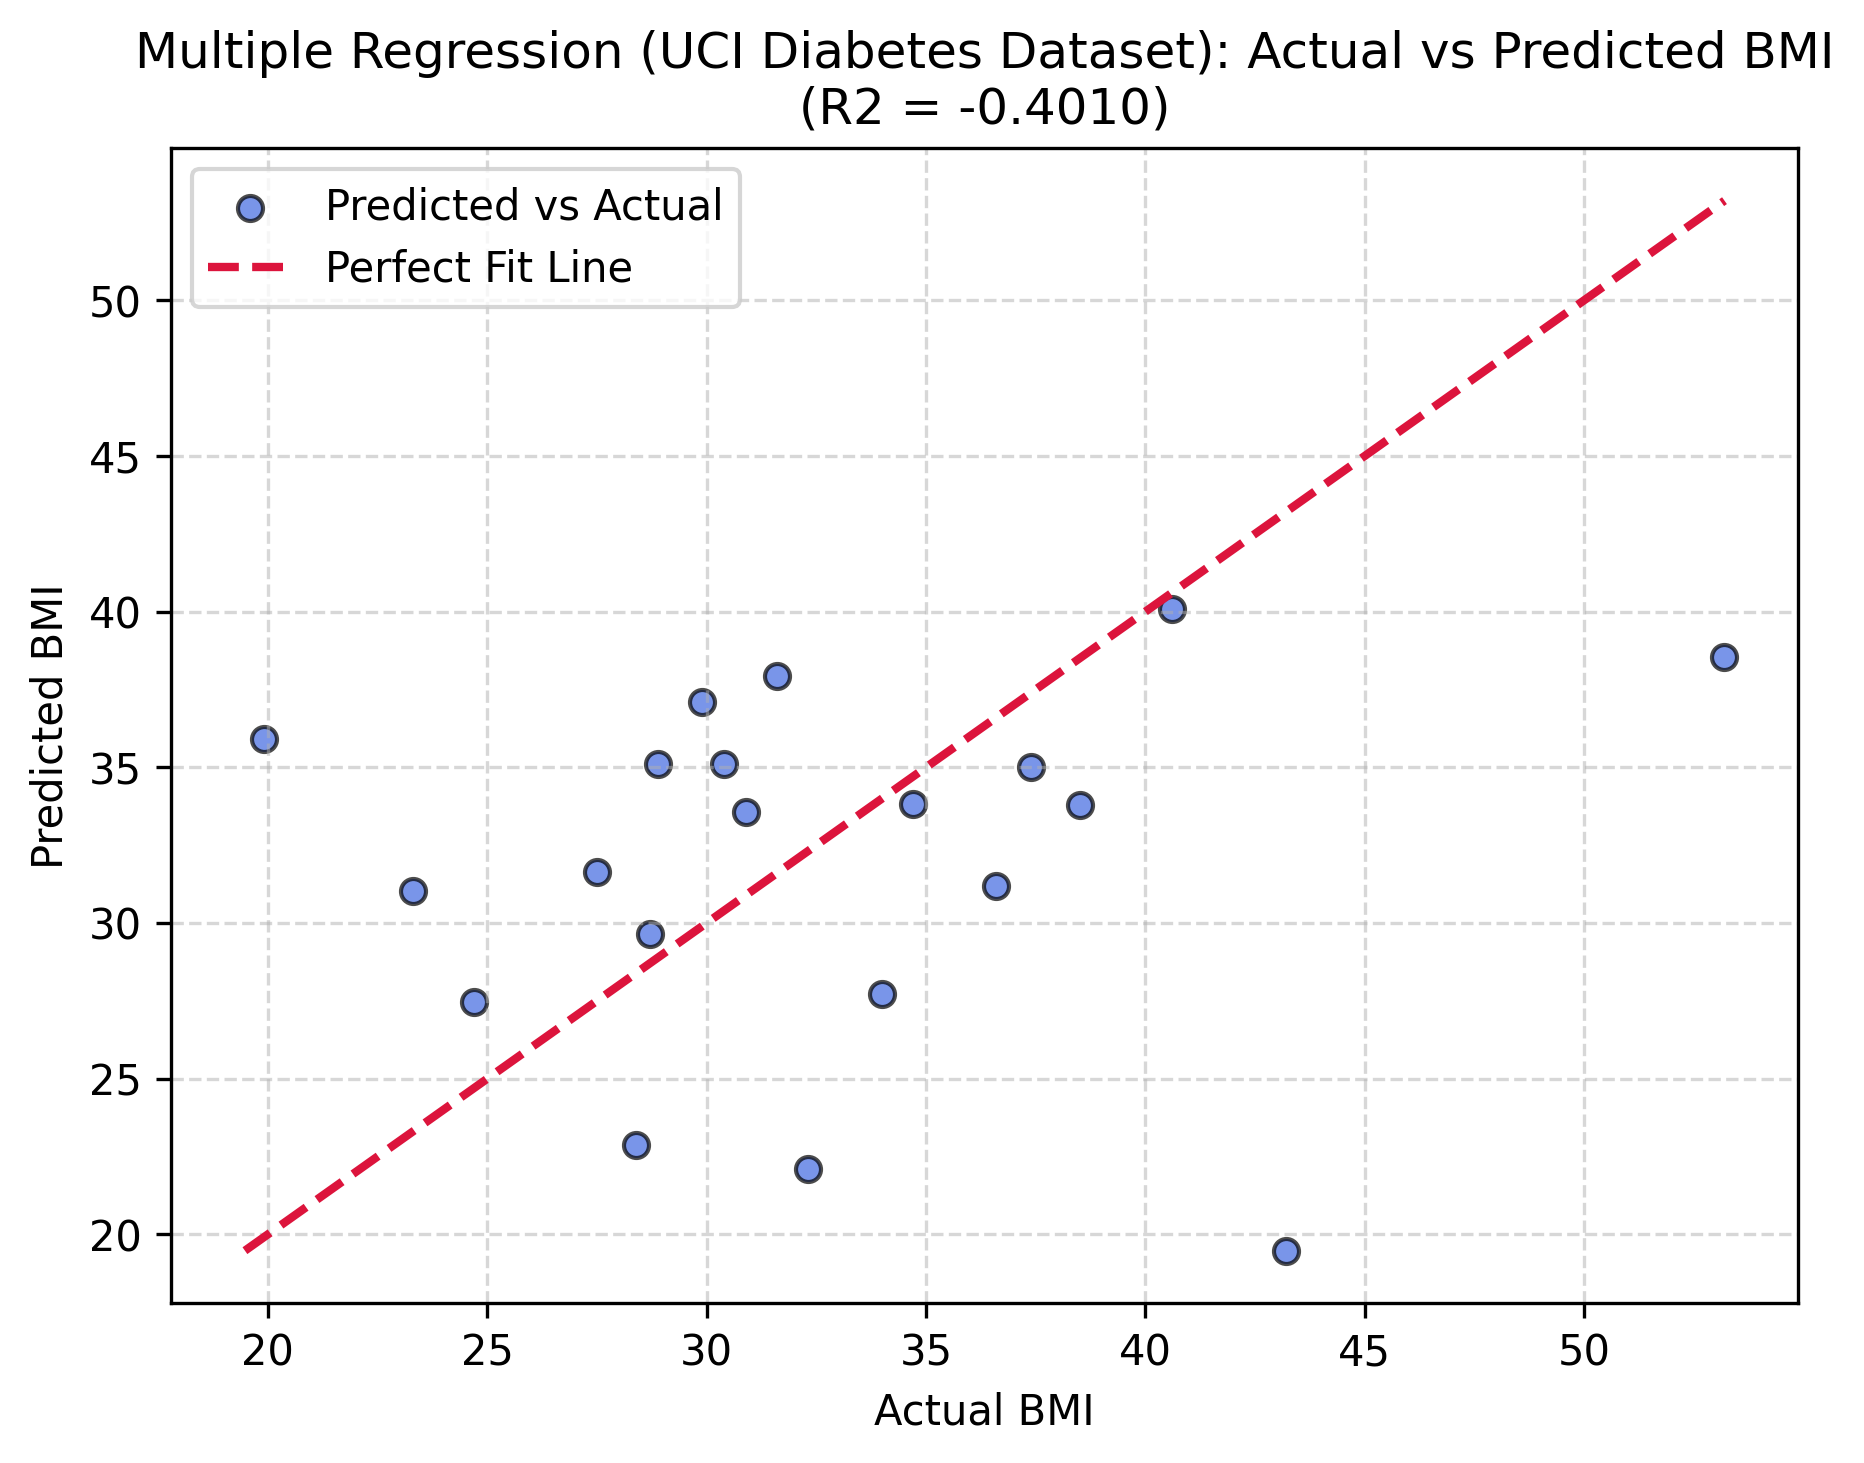

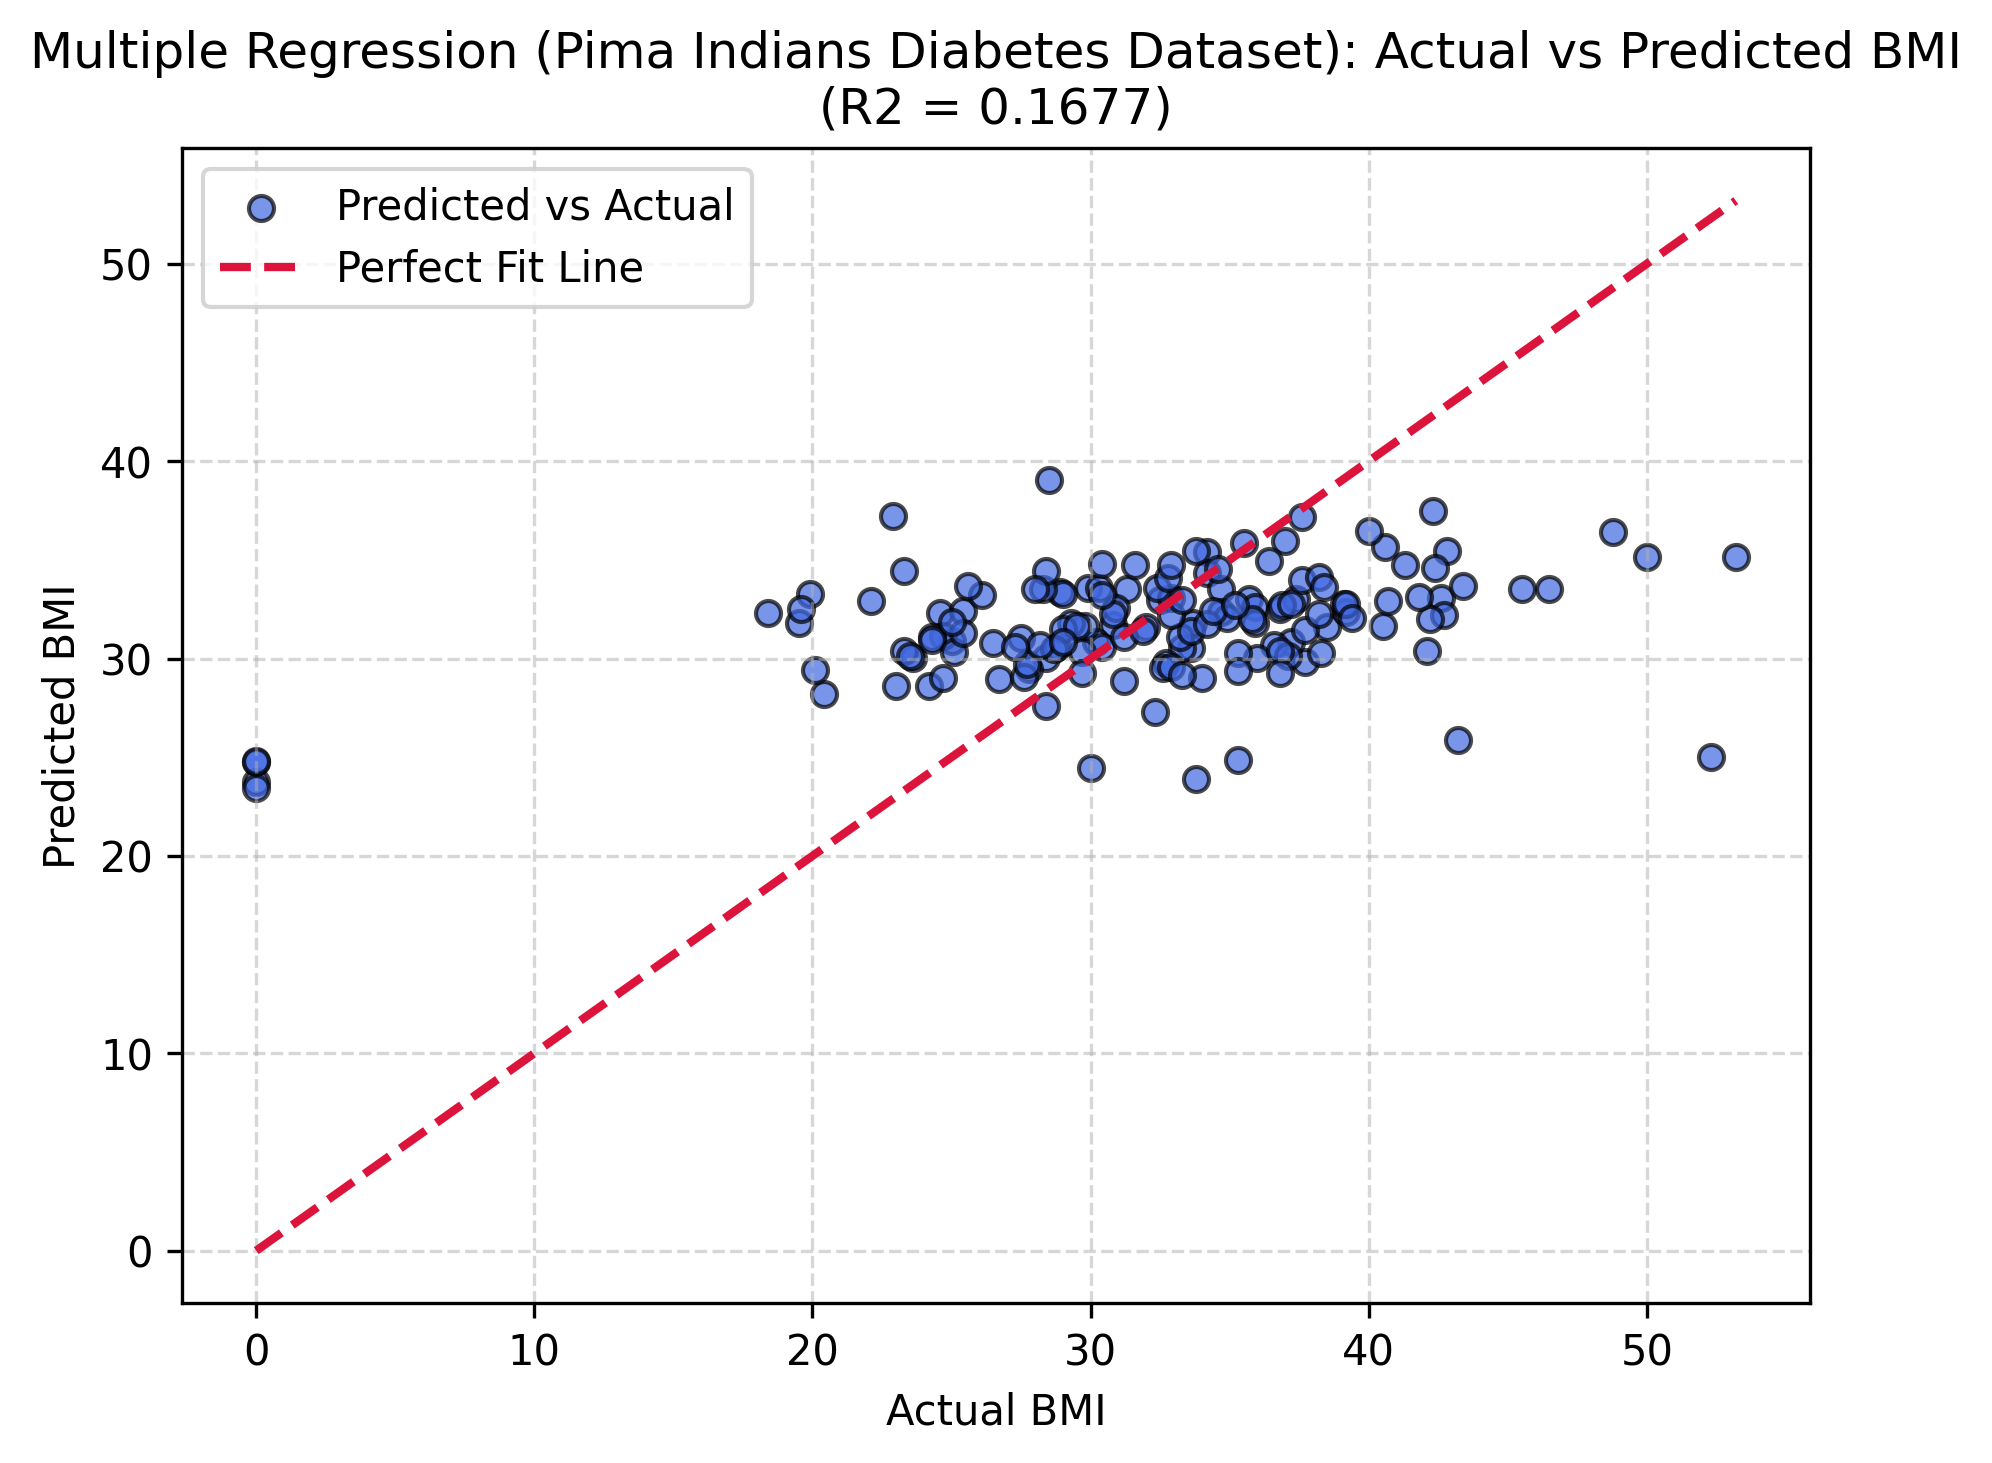

In [3]:
def multiple_regression_analysis(df, dataset_name):
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f'{dataset_name} - Multiple Regression Evaluation:')
    print(f'R2 Score: {r2:.4f}')
    print(f'Intercept: {model.intercept_:.4f}')
    for feat, coef in zip(features, model.coef_):
        print(f'Coefficient ({feat}): {coef:.4f}')
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred, color='royalblue', alpha=0.7, edgecolors='k', label='Predicted vs Actual')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Perfect Fit Line')
    plt.xlabel(f'Actual {target}')
    plt.ylabel(f'Predicted {target}')
    plt.title(f'Multiple Regression ({dataset_name}): Actual vs Predicted {target}\n(R2 = {r2:.4f})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

multiple_regression_analysis(uci_diabetes, 'UCI Diabetes Dataset')
multiple_regression_analysis(pima_diabetes, 'Pima Indians Diabetes Dataset')